In [75]:
# sucht that we can import our custom modules
import sys
import os
sys.path.append(os.path.abspath('../'))

## Graph Generation

In [76]:
from lib.graph_generator import GraphGenerator
from lib.utils import plot_graph, drop_pair

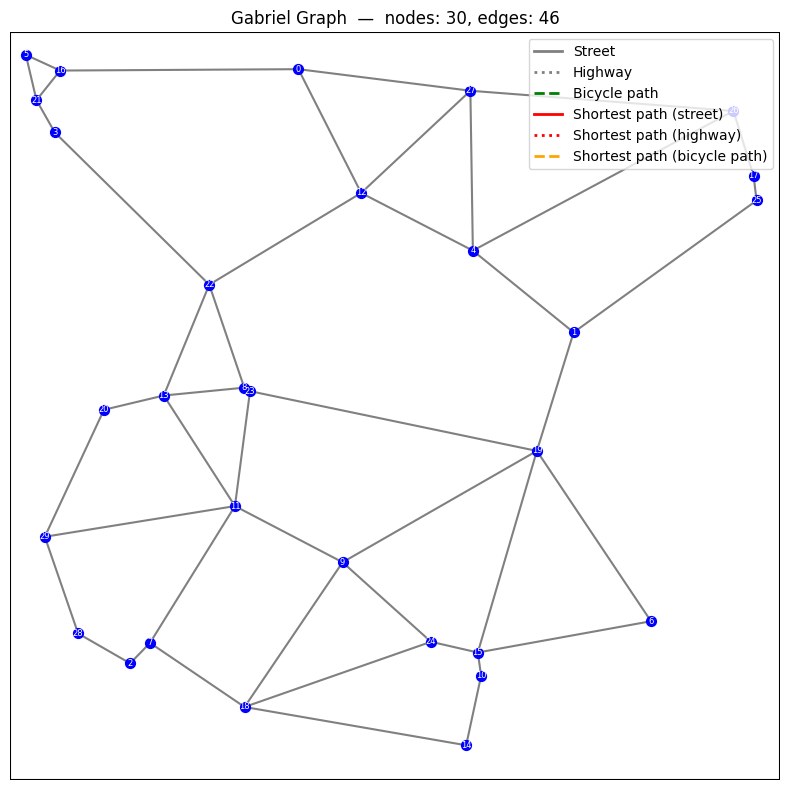

In [77]:
NUMBER_OF_NODES = 30

graph_gen = GraphGenerator(NUMBER_OF_NODES, seed=42)
GG = graph_gen.gabriel_graph()
plot_graph(GG, title="Gabriel Graph")

In [78]:
print("Example Edges and edge features:\n")
for u, v in list(GG.edges)[10:13]:
    print(f"Edge: {u} -> {v}:")
    print(f"\tDistance: {GG[u][v]['distance']}")

sum_distance = 0
sum_speed = 0
sum_duration = 0
num_edges = 0
for u, v in GG.edges:
    num_edges += 1
    sum_distance += GG[u][v]["distance"]
print(f"Average Distance: {sum_distance / num_edges}")

Example Edges and edge features:

Edge: 4 -> 12:
	Distance: 0.16426500470937033
Edge: 4 -> 26:
	Distance: 0.3864984205165294
Edge: 4 -> 27:
	Distance: 0.21382582881821538
Average Distance: 0.17671651699614194


## Graph Preprocessing

In [79]:
import torch
from torch_geometric.data import Data

In [80]:
import torch
from torch_geometric.data import Data

In [81]:
import lib.graph_preprocessor
from lib.graph_preprocessor import GraphPreprocessor

In [82]:
graph_preprocessor = GraphPreprocessor(GG)
pyg_data = graph_preprocessor.create_pyg_data()

adjacency = graph_preprocessor.adjacency_from_nx()
distance_matrix = graph_preprocessor.distance_matrix_from_nx()

Edge attr shape: torch.Size([152, 1])


In [83]:
from itertools import permutations, combinations
from torch_geometric.data import Data
from sklearn.model_selection import train_test_split
import networkx as nx

In [84]:
def all_shortest_path_instances(G, drop_short_paths=True):
    instances = []
    for s, t in combinations(G.nodes, 2):  # for s, t in permutations(G.nodes, 2) for both directions
        shortest_distance_path = None
        shortest_distance_path = nx.dijkstra_path(G, s, t, weight="distance")
        
        if drop_pair(shortest_distance_path, len(G.nodes)):
            shortest_distance_path = None

        if (shortest_distance_path != None):
            instances.append(
                {
                    "source": s,
                    "target": t,
                    "distance_path": shortest_distance_path,
                    "adjacency_matrix": graph_preprocessor.adjacency_from_nx(),
                    "distance_matrix": graph_preprocessor.distance_matrix_from_nx(),
                }
            )
    return instances

In [85]:
graph_preprocessor = GraphPreprocessor(GG)
pyg_data = graph_preprocessor.create_pyg_data()
pyg_data

Edge attr shape: torch.Size([152, 1])


Data(x=[31, 3], edge_index=[2, 152], edge_attr=[152, 1])

In [86]:
pairs = all_shortest_path_instances(GG, drop_short_paths=True)
print(f"Number of pairs: {len(pairs)}")

Number of pairs: 324


In [87]:
def create_instances(pairs, pyg_data):
    instances = []

    for p in pairs:
        instances.append(
            {
                "graph": pyg_data,
                "source": p["source"],
                "target": p["target"],
                "distance_path": p["distance_path"],
                "adjacency_matrix": p["adjacency_matrix"],
                "distance_matrix": p["distance_matrix"]
            }
        )
    return instances


instances = create_instances(pairs, pyg_data)
max_len = max(len(instance.get("distance_path") or []) for instance in instances)


train_instances, temp_instances = train_test_split(
    instances, test_size=0.3, random_state=50, shuffle=True
)
val_instances, test_instances = train_test_split(
    temp_instances, test_size=0.5, random_state=50, shuffle=True
)

combined_train_instances = (
    train_instances + val_instances
)  # To train model on all data except test_instances

In [88]:
from lib.shortest_path_dataset import ShortestPathDataset

dataset = ShortestPathDataset(
    train_instances, max_len=max_len, include_target_and_source=False
)
val_dataset = ShortestPathDataset(
    val_instances, max_len=max_len, include_target_and_source=False
)
test_dataset = ShortestPathDataset(
    test_instances, max_len=max_len, include_target_and_source=False
)
combined_train_dataset = ShortestPathDataset(
    combined_train_instances, max_len=max_len, include_target_and_source=False
)

tokenizer = dataset.tokenizer

sample = dataset[2]
print("Graph:", sample["graph"])
print("Source Node:", sample["source"].item())
print("Target Node:", sample["target"].item())
print()

print("Shortest Distance path:", sample["distance_path"].tolist())
decoded_path = dataset.tokenizer.decode(sample["distance_path"].tolist())
print("Shortest Distance path (decoded):", decoded_path)
print()

Graph: Data(x=[31, 3], edge_index=[2, 152], edge_attr=[152, 1])
Source Node: 7
Target Node: 20

Shortest Distance path: [34, 31, 2, 28, 29, 33, 32, 32, 32, 32, 32, 32, 32, 32, 32]
Shortest Distance path (decoded): ['<DIST>', '<BOS>', 2, 28, 29, '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']



In [89]:
from lib.augment_data_helpers import augment_with_reversed
augmented_dataset = augment_with_reversed(dataset, debug=False)
print(f"Original dataset size: {len(dataset)}")
print(f"Augmented dataset size: {len(augmented_dataset)}")

augment_combined_dataset = augment_with_reversed(combined_train_dataset)

Original dataset size: 226
Augmented dataset size: 452


In [90]:
from torch_geometric.loader import DataLoader
from torch_geometric.data import Batch

In [91]:
train_loader = DataLoader(augmented_dataset, batch_size=16, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
combined_train_loader = DataLoader(combined_train_dataset, batch_size=16, shuffle=False)

In [92]:
print("Number of instances:", len(augmented_dataset))
print("Number of batches:", len(train_loader))

Number of instances: 452
Number of batches: 29


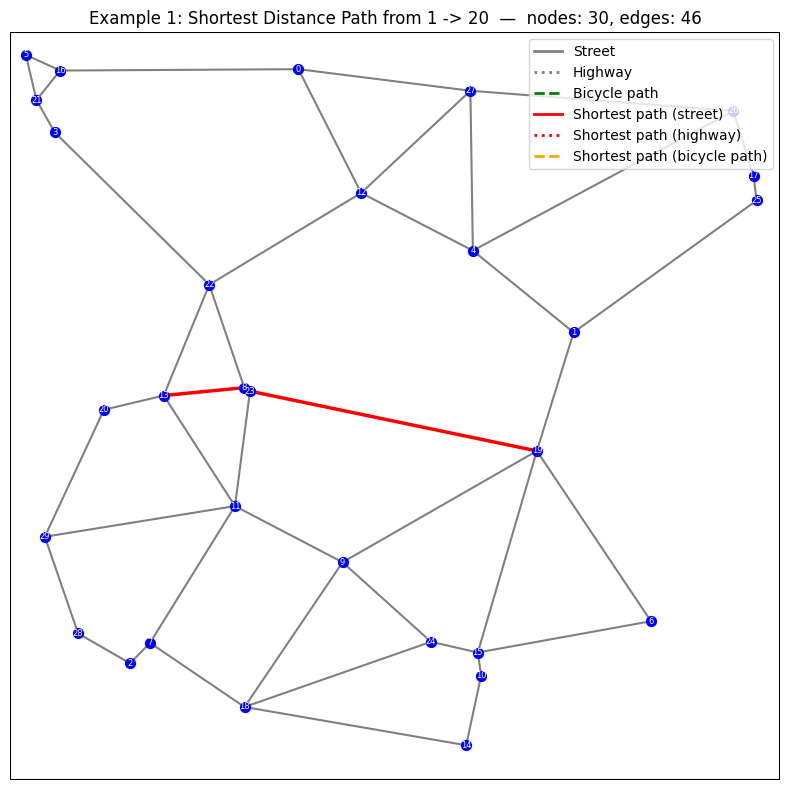

Source: 1, target: 20
Distance: ['<DIST>', '<BOS>', 19, 23, 8, 13, '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']



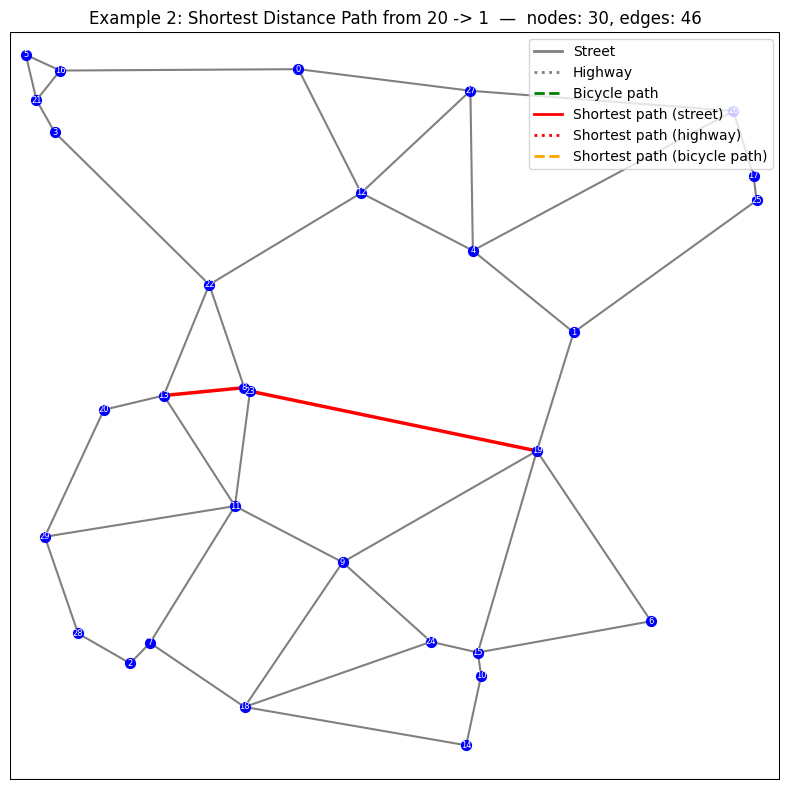

Source: 20, target: 1
Distance: ['<DIST>', '<BOS>', 13, 8, 23, 19, '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']



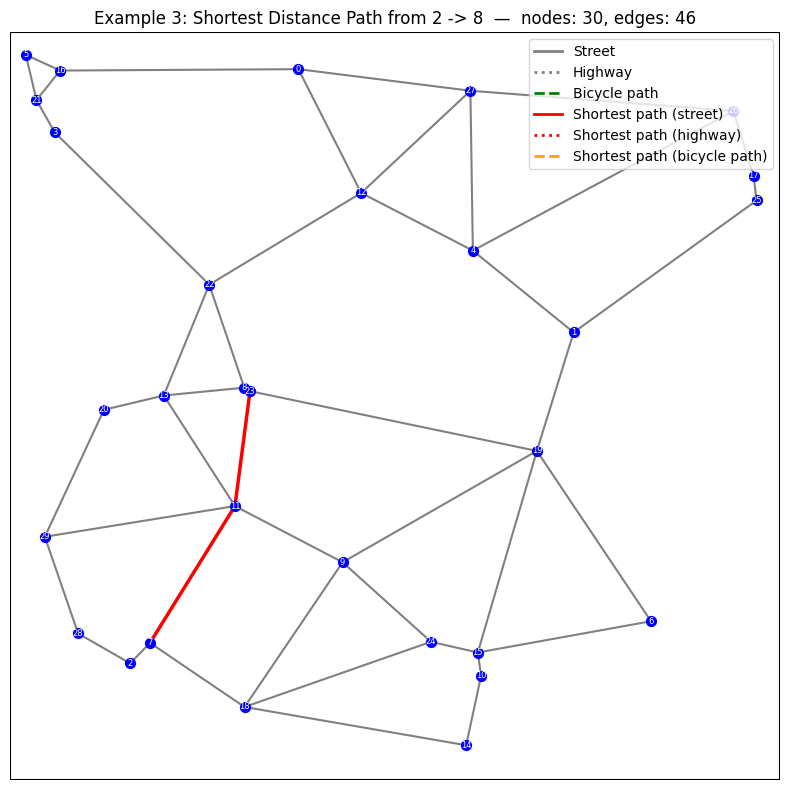

Source: 2, target: 8
Distance: ['<DIST>', '<BOS>', 7, 11, 23, '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']



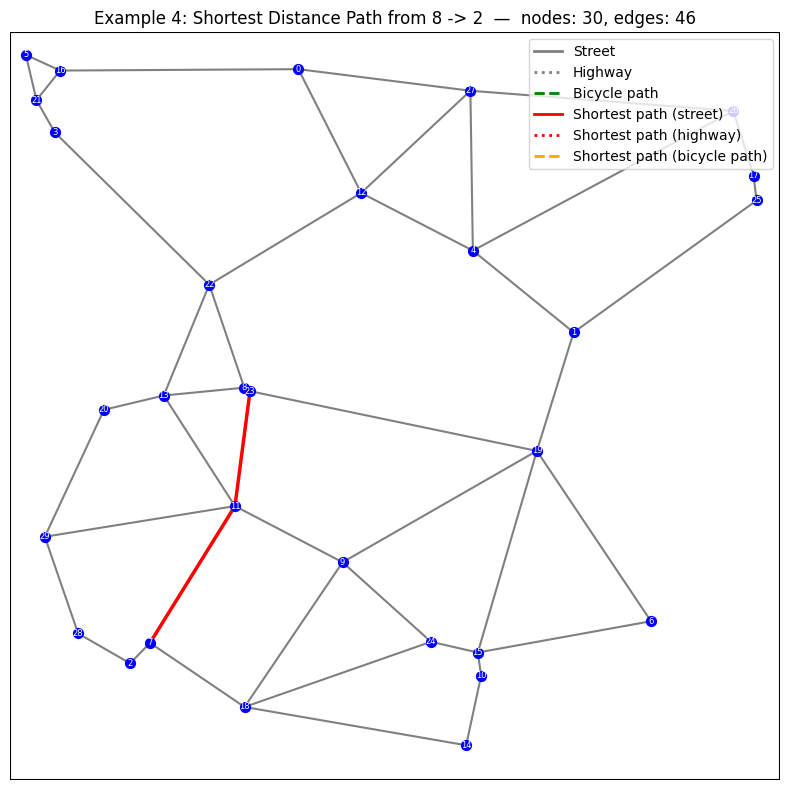

Source: 8, target: 2
Distance: ['<DIST>', '<BOS>', 23, 11, 7, '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']



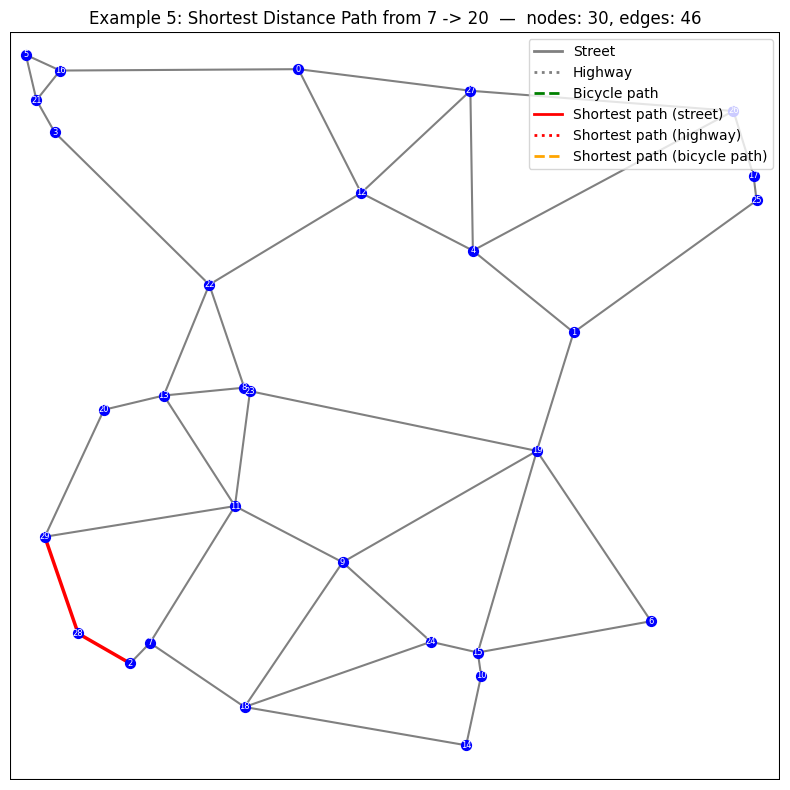

Source: 7, target: 20
Distance: ['<DIST>', '<BOS>', 2, 28, 29, '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']



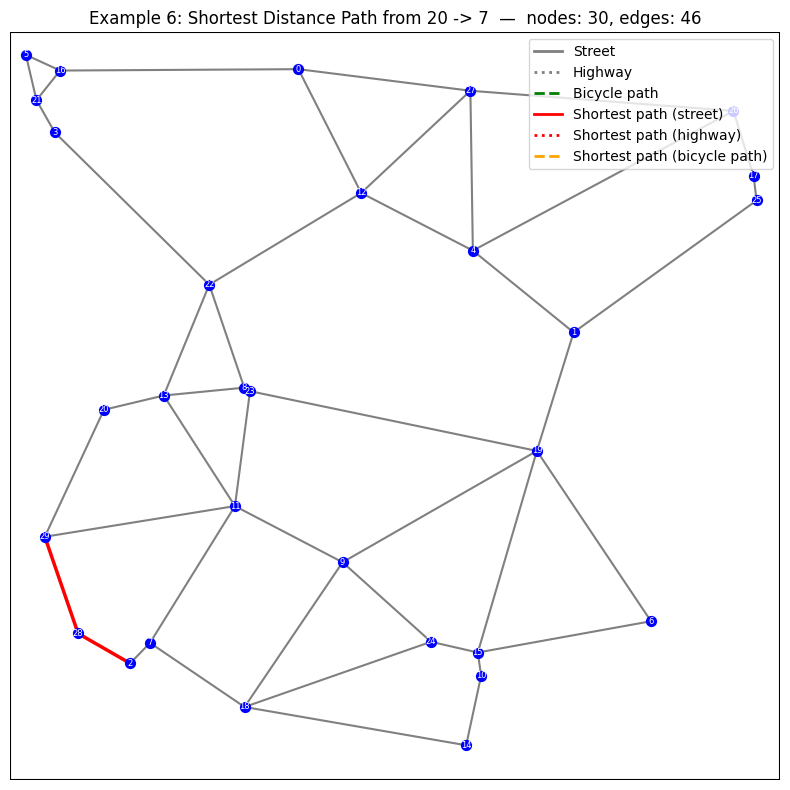

Source: 20, target: 7
Distance: ['<DIST>', '<BOS>', 29, 28, 2, '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']



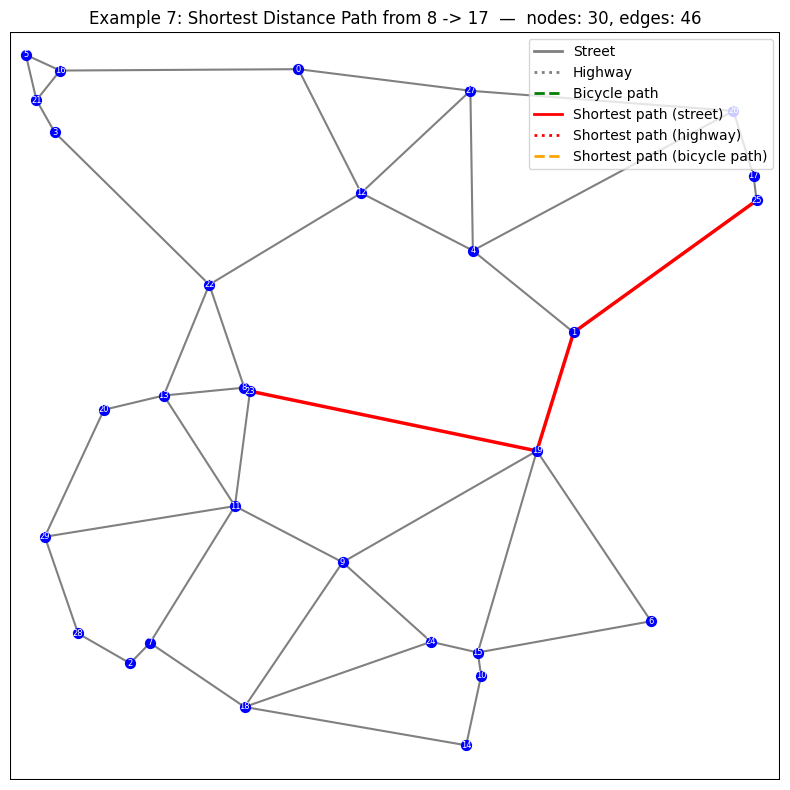

Source: 8, target: 17
Distance: ['<DIST>', '<BOS>', 23, 19, 1, 25, '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']



In [93]:
for i in range(len(augmented_dataset)):
    shortest_distance_path = dataset.get_decoded_path(
        augmented_dataset[i]["distance_path"]
    )
    source = augmented_dataset[i]["source"]
    target = augmented_dataset[i]["target"]

    plot_graph(
        GG,
        shortest_distance_path,
        f"Example {i+1}: Shortest Distance Path from {source} -> {target}",
    )

    print(
        f"Source: {augmented_dataset[i]['source']}, target: {augmented_dataset[i]['target']}"
    )
    print(
        f"Distance: {dataset.get_decoded_path(augmented_dataset[i]['distance_path'])}"
    )
    print()
    if i > 5:
        break

In [94]:
from lib.model_gnn import ShortestPathGNN

data = pyg_data
print("x:", data.x.shape)
print("edge_index:", data.edge_index.shape)
print("edge_attr:", data.edge_attr.shape)

model_encoder = ShortestPathGNN(in_dim=3, hidden_dim=16, edge_attr_dim=1)

out = model_encoder(data.x, data.edge_index, data.edge_attr)
print("Output shape:", out.shape)

x: torch.Size([31, 3])
edge_index: torch.Size([2, 152])
edge_attr: torch.Size([152, 1])
Output shape: torch.Size([31, 16])


In [95]:
def mask_out_invalid_next_hops(
    adjacency_matrix, decoder_model, last_token, logits_step
):
    if adjacency_matrix is None:
        return logits_step

    if 0 <= last_token < adjacency.size(0):
        valid_next = adjacency_matrix[last_token]
        masked_logits = torch.full_like(logits_step, float("-inf"))
        masked_logits[: valid_next.size(0)] = valid_next.float().log()

        masked_logits[decoder_model.eos_idx] = 0.0  # allow <eos>
        logits_step = logits_step + masked_logits
    else:
        logits_step[decoder_model.eos_idx] = logits_step[decoder_model.eos_idx] + 0.0

    return logits_step

In [96]:
def beam_search(
    gnn_model,
    decoder_model,
    graph,
    start_node,
    goal_node,
    padding_idx,
    beam_width=3,
    max_len=16,
    adjacency_matrix=None,
    criterion=None,
):
    device = next(gnn_model.parameters()).device
    graph = graph.to(device)
    x = graph.x
    edge_index = graph.edge_index
    edge_attr = graph.edge_attr

    criterion_token = (
        decoder_model.criterion_tokens[criterion] if criterion is not None else None
    )  # '<DIST>' if criterion == 'distance' else '<DUR>'
    token_ids = [
        decoder_model.padding_idx,
        decoder_model.bos_idx,
        decoder_model.eos_idx,
    ] + list(decoder_model.criterion_tokens.values())
    node_embeddings = gnn_model(x, edge_index, edge_attr)
    memory = node_embeddings.unsqueeze(0).expand(1, -1, -1)  # batch_size = 1

    if criterion_token is None:
        generated = [decoder_model.bos_idx]
    else:
        generated = [criterion_token, decoder_model.bos_idx]

    start_node = torch.tensor([start_node], device=device)
    goal_node = torch.tensor([goal_node], device=device)

    sequences = [(generated, 0, 0)]  # (sequence, score, distance)

    for step in range(max_len):
        all_candidates = []

        for seq, score, distance in sequences:
            if seq[-1] == decoder_model.eos_idx or seq[-1] == padding_idx:
                all_candidates.append((seq, score, distance))
                continue

            next_hop_logits = decoder_model(
                torch.tensor([seq], dtype=torch.long, device=memory.device),
                memory=memory,
                start_node=start_node,
                goal_node=goal_node,
            )[0, -1]

            next_hop_logits = mask_out_invalid_next_hops(
                adjacency_matrix, decoder_model, seq[-1], next_hop_logits
            )

            next_token_probs = torch.softmax(next_hop_logits, dim=-1)
            topk_probs, topk_indices = torch.topk(next_token_probs, k=beam_width)

            for prob, hop in zip(topk_probs, topk_indices):
                if (
                    (not seq[-1] in token_ids)
                    and (not hop.item() in token_ids)
                    and (adjacency_matrix is not None)
                    and (criterion is not None)
                ):
                    if GG.get_edge_data(seq[-1], hop.item()) is None:
                        tmp_distance = 0
                    else:
                        edge_attr_key = (
                            "duration" if criterion == "duration" else "distance"
                        )
                        if criterion in ["car_distance", "bike_distance"]:
                            edge_attr_key = "distance"
                        elif criterion in ["car_duration", "bike_duration"]:
                            edge_attr_key = "duration"
                        tmp_distance = GG.get_edge_data(seq[-1], hop.item())[
                            edge_attr_key
                        ]
                else:
                    tmp_distance = 0
                candidate = (
                    seq + [hop.item()],
                    score - prob.log().item(),
                    distance + tmp_distance,
                )
                all_candidates.append(candidate)

        all_candidates = sorted(all_candidates, key=lambda tup: tup[1])
        sequences = all_candidates[:beam_width]

    return sequences[0]  # return the best sequence

In [97]:
def greedy_decode(
    gnn_model,
    decoder_model,
    graph,
    start_node,
    goal_node,
    padding_idx,
    max_len=16,
    adjacency_matrix=None,
    criterion=None,
):
    device = next(gnn_model.parameters()).device
    graph = graph.to(device)
    x = graph.x
    edge_index = graph.edge_index
    edge_attr = graph.edge_attr

    criterion_token = decoder_model.criterion_tokens[criterion] or None
    node_embeddings = gnn_model(x, edge_index, edge_attr)  # [num_nodes, embeda_dim]
    memory = node_embeddings.unsqueeze(0).expand(1, -1, -1)  # [1, num_nodes, embed_dim]

    if criterion_token is None:
        generated = [decoder_model.bos_idx]
    else:
        generated = [criterion_token, decoder_model.bos_idx]

    start_node = torch.tensor([start_node], device=device)
    goal_node = torch.tensor([goal_node], device=device)

    for _ in range(max_len - 1):
        input_seq = torch.tensor([generated], dtype=torch.long, device=device)  # [1, t]
        tgt_mask = decoder_model.generate_square_subsequent_mask(input_seq.size(1))

        logits = decoder_model(
            input_seq,
            memory=memory,
            tgt_mask=tgt_mask,
            start_node=start_node,
            goal_node=goal_node,
        )  # [1, t, vocab_size]

        last_token = generated[-1]
        logits_step = logits[0, -1]  # [vocab_size]

        if last_token == decoder_model.bos_idx:
            last_token = start_node.item()

        # Mask invalid nodes based on the adjacency matrix
        logits_step = mask_out_invalid_next_hops(
            adjacency_matrix, decoder_model, last_token, logits_step
        )
        next_token = logits_step.argmax().item()

        if next_token == decoder_model.eos_idx or next_token == padding_idx:
            break

        generated.append(next_token)

    return generated

In [98]:
def decode_single_instance(
    loader,
    gnn_model,
    decoder_model,
    decode_fn="greedy",
    criterion="distance",
    beam_width=3,
):
    graph_batch = next(iter(loader))

    true_path = graph_batch[f"{criterion}_path"][0].tolist()
    start_node = graph_batch["source"][0].item()
    goal_node = graph_batch["target"][0].item()
    graph = graph_batch["graph"][0]
    adjacency_matrix = graph_batch["adjacency_matrix"][0]

    print(90 * "-")
    print(f"{criterion.upper()}, {decode_fn.upper()}:")
    print(90 * "-")
    print("Start node:", start_node)
    print("End node:", goal_node)
    print("True path:", true_path)
    print("True path (decoded):", tokenizer.decode(true_path))
    print()


    token_ids = [
        decoder_model.padding_idx,
        decoder_model.bos_idx,
        decoder_model.eos_idx,
    ] + list(decoder_model.criterion_tokens.values())
    true_path = [x for x in true_path if x not in token_ids]

    if decode_fn == "greedy":
        predicted_path = greedy_decode(
            gnn_model,
            decoder_model,
            graph,
            start_node,
            goal_node=goal_node,
            padding_idx=decoder_model.padding_idx,
            max_len=16,
            adjacency_matrix=adjacency_matrix,
            criterion=criterion,
        )
    elif decode_fn == "beam":
        predicted_path = beam_search(
            gnn_model,
            decoder_model,
            graph,
            start_node,
            goal_node=goal_node,
            beam_width=beam_width,
            padding_idx=decoder_model.padding_idx,
            max_len=16,
            adjacency_matrix=adjacency_matrix,
            criterion=criterion,
        )[0]

    print(
        "Predicted path:",
        tokenizer.decode([x for x in predicted_path if x not in token_ids]),
    )
    print("Target path:   ", [x for x in true_path if x not in token_ids])
    print()

In [99]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [100]:
def is_path_valid(path, adj_matrix):
    return all(adj_matrix[path[i], path[i + 1]].item() for i in range(len(path) - 1))


def get_relativ_path_length(
    path_is_valid,
    predicted_path,
    true_path,
    distance_matrix,
    adjacency_matrix,
    start_node,
    goal_node,
    decoder_model,
):
    token_ids = [
        decoder_model.padding_idx,
        decoder_model.bos_idx,
        decoder_model.eos_idx,
    ] + list(decoder_model.criterion_tokens.values())
    predicted_path = [start_node] + predicted_path + [goal_node]
    predicted_path = [x for x in predicted_path if x not in token_ids]

    true_path = [start_node] + true_path + [goal_node]
    true_path = [x for x in true_path if x not in token_ids]

    dist = distance_matrix
    adj = adjacency_matrix

    assert (
        is_path_valid(predicted_path, adj) == path_is_valid
    ), "Something is wrong with the path validity check."
    assert (
        dist.shape == adj.shape
    ), "Shapes of distance and adjacency matrices do not match."

    # verify that all adjacency connections have a distance > 0 and distance != inf
    invalid = (adj == 1) & ((dist <= 0) | torch.isinf(dist))
    assert (
        torch.any(invalid) == False
    ), "There are invalid connections in the adjacency matrix with distance <= 0 or inf."

    hop_distances_true_path = [
        distance_matrix[true_path[i], true_path[i + 1]]
        for i in range(len(true_path) - 1)
    ]

    hop_distances_predicted_path = [
        distance_matrix[predicted_path[i], predicted_path[i + 1]]
        for i in range(len(predicted_path) - 1)
    ]

    total_distance_true_path = sum(hop_distances_true_path)
    total_distance_predicted_path = sum(hop_distances_predicted_path)

    return (
        total_distance_predicted_path / total_distance_true_path
        if total_distance_true_path > 0
        else float("inf")
    )


def check_path_validity(
    path,
    adjacency_matrix,
    decoder_model,
    start_node,
    goal_node,
    padding_idx,
    print_path=True,
):
    token_ids = [
        decoder_model.padding_idx,
        decoder_model.bos_idx,
        decoder_model.eos_idx,
    ] + list(decoder_model.criterion_tokens.values())
    path = [start_node] + path + [goal_node]
    path = [x for x in path if x not in token_ids]

    if print_path:
        print(path)
    for u, v in zip(path, path[1:]):
        if u in token_ids or v in token_ids:
            continue
        if not adjacency_matrix[u, v]:
            return False

    return True

In [101]:
def evaluate_model_on_loader(
    gnn_model,
    decoder_model,
    loader,
    device,
    max_len=16,
    decoder_fn="greedy",
    criterion="distance",
    print_all=True,
):
    gnn_model.eval()
    decoder_model.eval()
    num_correct = 0
    num_incorrect = 0
    paths = []

    with torch.no_grad():
        for batch_idx, batch in enumerate(loader):
            graph_data = batch["graph"].to(device)

            batch_size = batch[f"{criterion}_path"].size(0)

            for i in range(batch_size):
                true_path = batch[f"{criterion}_path"][i].tolist()
                start_node = batch["source"][i].item()
                goal_node = batch["target"][i].item()
                graph = graph_data[i]
                adjacency_matrix = batch["adjacency_matrix"][i]

                if decoder_fn == "greedy":
                    predicted_path = greedy_decode(
                        gnn_model,
                        decoder_model,
                        graph,
                        start_node=start_node,
                        goal_node=goal_node,
                        padding_idx=decoder_model.padding_idx,
                        max_len=max_len,
                        adjacency_matrix=adjacency_matrix,
                        criterion=criterion,
                    )
                else:
                    predicted_path = beam_search(
                        gnn_model,
                        decoder_model,
                        graph,
                        start_node=start_node,
                        goal_node=goal_node,
                        padding_idx=decoder_model.padding_idx,
                        beam_width=3,
                        max_len=max_len,
                        adjacency_matrix=adjacency_matrix,
                        criterion=criterion,
                    )[0]

                path_is_valid = check_path_validity(
                    predicted_path,
                    adjacency_matrix,
                    decoder_model,
                    start_node,
                    goal_node,
                    decoder_model.padding_idx,
                    print_path=False,
                )
                if path_is_valid:
                    num_correct += 1
                else:
                    num_incorrect += 1
                # Trim PAD and EOS tokens
                predicted_preferred_fraction = true_preferred_fraction = 0
                predicted_path = [
                    x
                    for x in predicted_path
                    if x != decoder_model.padding_idx
                    and x != decoder_model.eos_idx
                    and x != decoder_model.bos_idx
                    and x not in decoder_model.criterion_tokens.values()
                ]

                true_clean = [
                    x
                    for x in true_path
                    if x != decoder_model.padding_idx
                    and x != decoder_model.eos_idx
                    and x != decoder_model.bos_idx
                    and x not in decoder_model.criterion_tokens.values()
                ]

                relativ_path_length = None  # Default value if path is invalid

            
                relativ_path_length = get_relativ_path_length(
                    path_is_valid,
                    predicted_path,
                    true_clean,
                    distance_matrix,
                    adjacency_matrix,
                    start_node,
                    goal_node,
                    decoder_model,
                )

         

                if print_all:
                    print(f"[Sample {batch_idx * batch_size + i}]")
                    print("Start:", start_node, "| Goal:", goal_node)
                    print("True path:     ", true_clean)
                    print("Predicted path:", predicted_path)
                    print("Path valid:", path_is_valid)
                    print()
                paths.append(
                    (
                        start_node,
                        goal_node,
                        true_clean,
                        predicted_path,
                        path_is_valid,
                        relativ_path_length,
                    )
                )
    return paths

In [102]:
def get_path_validity_over_all_paths(paths):
    total = len(paths)
    correct = sum(1 for _, _, _, _, valid, _ in paths if valid)
    return correct/total

def get_relative_path_length_over_all_paths(paths):
    relative_lengths = [length for _, _, _, _, valid, length in paths if valid and length is not None]
    if relative_lengths:
        avg_length = sum(relative_lengths) / len(relative_lengths)
        return avg_length
    else:
        return float('inf')

In [103]:
import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader


@torch.no_grad()
def validation_step(gnn_model, decoder_model, batch, device):
    gnn_model.eval()
    decoder_model.eval()

    graph_data = batch["graph"].to(device)
    x = graph_data.x
    edge_index = graph_data.edge_index
    edge_attr = graph_data.edge_attr
    start_node = batch["source"].to(device)
    goal_node = batch["target"].to(device)

    node_embeddings = gnn_model(x, edge_index, edge_attr)

    total_loss = 0

    for criterion in [
        "distance",
    ]:
        path_tensor = batch[f"{criterion}_path"].to(device)
        decoder_input = path_tensor[:, :-1]
        target_output = path_tensor[:, 1:]
        tgt_mask = decoder_model.generate_square_subsequent_mask(decoder_input.size(1))

        memory = node_embeddings.unsqueeze(0).expand(decoder_input.size(0), -1, -1)

        logits = decoder_model(
            decoder_input,
            memory=memory,
            tgt_mask=tgt_mask,
            start_node=start_node,
            goal_node=goal_node,
            criterion=[criterion] * decoder_input.size(0),
        )

        ignore_index = decoder_model.criterion_tokens[criterion]

        loss = F.cross_entropy(
            logits.reshape(-1, logits.size(-1)),
            target_output.reshape(-1),
            ignore_index=ignore_index,
        )
        total_loss += loss

    return total_loss.item()


def training_step(gnn_model, decoder_model, batch, optimizer, device):
    gnn_model.train()
    decoder_model.train()

    graph_data = batch["graph"].to(device)
    x = graph_data.x
    edge_index = graph_data.edge_index
    edge_attr = graph_data.edge_attr
    start_node = batch["source"].to(device)
    goal_node = batch["target"].to(device)

    node_embeddings = gnn_model(x, edge_index, edge_attr)

    total_loss = 0

    for criterion in [
        "distance"
    ]:
        path_tensor = batch[f"{criterion}_path"].to(device)
        decoder_input = path_tensor[:, :-1]
        target_output = path_tensor[:, 1:]
        tgt_mask = decoder_model.generate_square_subsequent_mask(decoder_input.size(1))

        memory = node_embeddings.unsqueeze(0).expand(decoder_input.size(0), -1, -1)

        logits = decoder_model(
            decoder_input,
            memory=memory,
            tgt_mask=tgt_mask,
            start_node=start_node,
            goal_node=goal_node,
            criterion=[criterion] * decoder_input.size(0),
        )
        ignore_index = decoder_model.criterion_tokens[criterion]

        loss = F.cross_entropy(
            logits.reshape(-1, logits.size(-1)),
            target_output.reshape(-1),
            ignore_index=ignore_index,
        )
        total_loss += loss

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    return total_loss.item()


def train_model(
    gnn_model,
    decoder_model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs=10,
    verbose=True,
):

    epoch_loss = []
    path_validity = []
    relativ_path_lenght = []

    for epoch in range(num_epochs):
        total_train_loss = 0
        for batch in train_loader:
            loss = training_step(gnn_model, decoder_model, batch, optimizer, device)
            total_train_loss += loss
        avg_train_loss = total_train_loss / len(train_loader)

        total_val_loss = 0
        for batch in val_loader:
            loss = validation_step(gnn_model, decoder_model, batch, device)
            total_val_loss += loss
        avg_val_loss = total_val_loss / len(val_loader)

        paths = evaluate_model_on_loader(
            gnn_model,
            decoder_model,
            val_loader,
            device,
            max_len=NUMBER_OF_NODES,
            print_all=False,
        )

        avg_path_validity = get_path_validity_over_all_paths(paths)
        avg_relative_path_length = get_relative_path_length_over_all_paths(paths)

        epoch_loss.append((avg_train_loss, avg_val_loss))
        path_validity.append(avg_path_validity)
        relativ_path_lenght.append(avg_relative_path_length)

        if verbose:
            print(
                f"Epoch {epoch + 1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Path Validity: {avg_path_validity:.4f} | Relative Path Length: {avg_relative_path_length:.4f}"
            )

    return epoch_loss, path_validity, relativ_path_lenght

In [104]:
from lib.model_gnn import ShortestPathGNN
from lib.model_gnn_baseline import ShortestPathGNNBaseline
from lib.model_transformer import GraphTransformerDecoder
from itertools import product
import numpy as np

In [ ]:
# - learning_rate: 0.001
# - gnn_hidden_dim: 128
# - transformer_hidden_dim: 256
# - num_attention_heads: 4
# - dropout_rate: 0.3

In [106]:
# Use Baseline model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gnn_model = ShortestPathGNN(in_dim=3, hidden_dim=128, out_dim=256, edge_attr_dim=1).to(
    device
)
decoder_model = GraphTransformerDecoder(dataset, embed_dim=256, num_heads=4, dropout=0.3, max_len=max_len, profile=None).to(device)
optimizer = torch.optim.Adam(list(gnn_model.parameters()) + list(decoder_model.parameters()), lr=0.001)

losses, path_validity, relativ_path_length = train_model(gnn_model, decoder_model, combined_train_loader, test_loader, optimizer, device, num_epochs=40)

Epoch 1/40 | Train Loss: 1.3407 | Val Loss: 0.6595 | Path Validity: 0.0204 | Relative Path Length: 1.5084
Epoch 2/40 | Train Loss: 0.6663 | Val Loss: 0.5314 | Path Validity: 0.1224 | Relative Path Length: 1.3063
Epoch 3/40 | Train Loss: 0.5601 | Val Loss: 0.4740 | Path Validity: 0.1224 | Relative Path Length: 1.2906
Epoch 4/40 | Train Loss: 0.5091 | Val Loss: 0.4591 | Path Validity: 0.1224 | Relative Path Length: 1.3063
Epoch 5/40 | Train Loss: 0.4799 | Val Loss: 0.4407 | Path Validity: 0.2245 | Relative Path Length: 1.6132
Epoch 6/40 | Train Loss: 0.4369 | Val Loss: 0.4067 | Path Validity: 0.2449 | Relative Path Length: 1.4704
Epoch 7/40 | Train Loss: 0.3965 | Val Loss: 0.3783 | Path Validity: 0.3061 | Relative Path Length: 1.3998
Epoch 8/40 | Train Loss: 0.3466 | Val Loss: 0.3283 | Path Validity: 0.2653 | Relative Path Length: 1.4277
Epoch 9/40 | Train Loss: 0.3211 | Val Loss: 0.3257 | Path Validity: 0.3469 | Relative Path Length: 1.2862
Epoch 10/40 | Train Loss: 0.2982 | Val Loss: 0

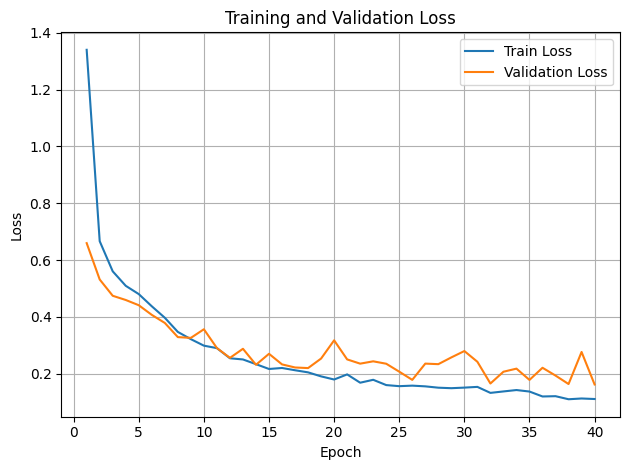

In [107]:
import matplotlib.pyplot as plt
import numpy as np


def plot_training_loss(losses):
    losses = np.array(losses)
    train_loss = losses[:, 0]
    val_loss = losses[:, 1]
    epochs = np.arange(1, len(losses) + 1)

    plt.plot(epochs, train_loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_training_loss(losses)

In [108]:
# Beam Search, Distance
decode_single_instance(
    train_loader, gnn_model, decoder_model, decode_fn="beam", criterion="distance"
)
# Beam Search, Distance
decode_single_instance(
    train_loader, gnn_model, decoder_model, decode_fn="greedy", criterion="distance"
)

------------------------------------------------------------------------------------------
DISTANCE, BEAM:
------------------------------------------------------------------------------------------
Start node: 1
End node: 20
True path: [34, 31, 19, 23, 8, 13, 33, 32, 32, 32, 32, 32, 32, 32, 32]
True path (decoded): ['<DIST>', '<BOS>', 19, 23, 8, 13, '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']

Predicted path: [19, 23, 8, 13]
Target path:    [19, 23, 8, 13]

------------------------------------------------------------------------------------------
DISTANCE, GREEDY:
------------------------------------------------------------------------------------------
Start node: 1
End node: 20
True path: [34, 31, 19, 23, 8, 13, 33, 32, 32, 32, 32, 32, 32, 32, 32]
True path (decoded): ['<DIST>', '<BOS>', 19, 23, 8, 13, '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']

Predicted path: [19, 23, 8, 13]
Target path:    [19, 23, 8, 13]



In [109]:
paths_validation_beam_distance = evaluate_model_on_loader(
    gnn_model,
    decoder_model,
    test_loader,
    device,
    max_len=16,
    decoder_fn="beam",
    criterion="distance",
    print_all=False,
)
paths_validation_greedy_distance = evaluate_model_on_loader(
    gnn_model,
    decoder_model,
    test_loader,
    device,
    max_len=16,
    decoder_fn="greedy",
    criterion="distance",
    print_all=False,
)

In [110]:
def print_path_validicity(paths):
    total = len(paths)
    correct = sum(1 for _, _, _, _, valid, _ in paths if valid)
    print(f"Path Validity: {correct}/{total} = {correct / total:.2%}")


def print_relative_path_length(paths):
    relative_lengths = [
        length
        for _, _, _, _, valid, length in paths
        if valid == True and length is not None
    ]
    if len(relative_lengths) > 0:
        avg_length = sum(relative_lengths) / len(relative_lengths)
        print(f"Average relative path length: {avg_length:.2f}")
    else:
        print("No valid paths found.")

In [111]:
print("Distance (Beam Search and Greedy Search)")
print_path_validicity(paths_validation_beam_distance)
print_relative_path_length(paths_validation_beam_distance)
print_path_validicity(paths_validation_greedy_distance)
print_relative_path_length(paths_validation_greedy_distance)
print()

Distance (Beam Search and Greedy Search)
Path Validity: 24/49 = 48.98%
Average relative path length: 1.10
Path Validity: 31/49 = 63.27%
Average relative path length: 1.13

